In [2]:

import os, random, time, math, json, yaml, shutil, glob, itertools
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision

import timm
import cv2
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.metrics import f1_score, classification_report, confusion_matrix

# Semillas para reproducibilidad
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
device


'cuda'

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("zlatan599/garbage-dataset-classification", force_download=True)

print("Path to dataset files:", path)

100%|██████████| 121M/121M [00:00<00:00, 137MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/zlatan599/garbage-dataset-classification/versions/5


In [4]:
import os
import shutil

source_dir = "/root/.cache/kagglehub/datasets/zlatan599/garbage-dataset-classification/versions/5"
destination_dir = "data/raw"

# Create the destination directory if it doesn't exist
os.makedirs(destination_dir, exist_ok=True)

# Move the contents of the source directory to the destination directory
for item in os.listdir(source_dir):
    source_item = os.path.join(source_dir, item)
    destination_item = os.path.join(destination_dir, item)
    # Use shutil.move which handles both files and directories
    shutil.move(source_item, destination_item)

print(f"Moved contents from {source_dir} to {destination_dir}")

Moved contents from /root/.cache/kagglehub/datasets/zlatan599/garbage-dataset-classification/versions/5 to data/raw


In [5]:
import pandas as pd
metadata = []
classes = ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
for class_label in classes:
    class_dir = os.path.join(destination_dir, class_label)
    for filename in os.listdir(class_dir):
        relative_path = os.path.join(class_label, filename)
        metadata.append({'filename': relative_path, 'label': class_label})
df = pd.DataFrame(metadata)
df.to_csv(os.path.join(destination_dir, 'metadata.csv'), index=False)

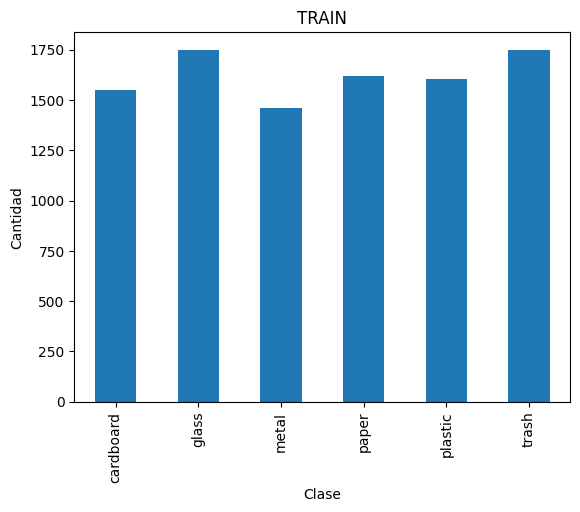

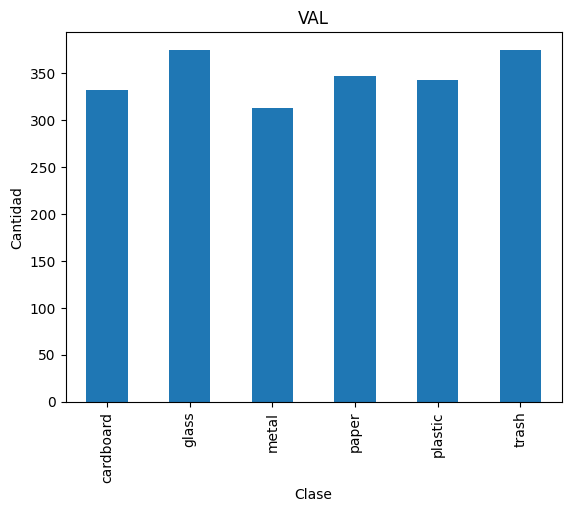

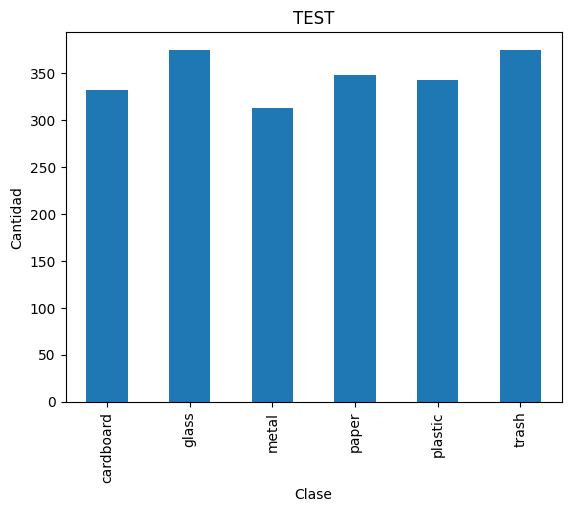

In [12]:
train_df = pd.read_csv("data/splits/train.csv")
val_df = pd.read_csv("data/splits/val.csv")
test_df = pd.read_csv("data/splits/test.csv")

train_csv = "data/splits/train.csv"
val_csv = "data/splits/val.csv"
test_csv = "data/splits/test.csv"


def show_distribution(df, title):
    dist = df['label'].value_counts().sort_index()
    ax = dist.plot(kind='bar')
    ax.set_title(title); ax.set_xlabel('Clase'); ax.set_ylabel('Cantidad')
    plt.show()

show_distribution(train_df, "TRAIN")
show_distribution(val_df, "VAL")
show_distribution(test_df, "TEST")


In [13]:
# from transforms import get_train_transforms, get_valid_transforms
from datasets import ImageCSVDataset

In [14]:
def get_train_transforms(image_size):
    return A.Compose([
        A.RandomResizedCrop(size=(image_size, image_size), scale=(0.6, 1.0)),
        A.HorizontalFlip(p=0.5),
        A.Affine(translate_percent=(-0.05, 0.05), scale=(0.9, 1.1), rotate=(-10, 10), shear=(-5, 5), p=0.5),
        A.ColorJitter(p=0.5),
        A.RandomBrightnessContrast(p=0.5),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2()
    ])

def get_val_transforms(image_size):
    return A.Compose([
        A.LongestMaxSize(max_size=image_size),
        A.PadIfNeeded(min_height=image_size, min_width=image_size, border_mode=0),
        A.CenterCrop(height=image_size, width=image_size),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2()
    ])

In [15]:
IMG_SIZE = 256

In [16]:
from tabulate import tabulate
import subprocess, sys

train_ds = ImageCSVDataset(train_csv, transforms=get_train_transforms(IMG_SIZE))
val_ds   = ImageCSVDataset(val_csv,   transforms=get_val_transforms(IMG_SIZE), class2idx=train_ds.class2idx)

train_dl = DataLoader(train_ds, batch_size=64, shuffle=True,  num_workers=2, pin_memory=True)
val_dl   = DataLoader(val_ds,   batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

# mostrar con tabulate
try:
    rows = [
    ("train_ds", len(train_ds)),
    ("val_ds", len(val_ds)),
    ("train_dl [batches]", len(train_dl)),
    ("val_dl   [batches]", len(val_dl)),
    ("class2idx (train_ds)", ", ".join(f"{k}:{v}" for k, v in train_ds.class2idx.items()))
]

    print(tabulate(rows, headers=["Item", "Value"], tablefmt="github"))
except Exception:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "tabulate"])




| Item                 | Value                                                      |
|----------------------|------------------------------------------------------------|
| train_ds             | 9730                                                       |
| val_ds               | 2085                                                       |
| train_dl [batches]   | 153                                                        |
| val_dl   [batches]   | 33                                                         |
| class2idx (train_ds) | cardboard:0, glass:1, metal:2, paper:3, plastic:4, trash:5 |


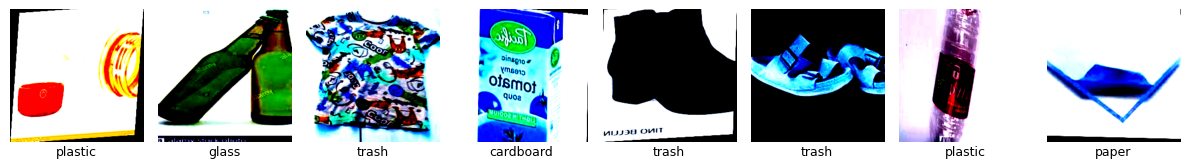

In [17]:
def show_batch(dloader, idx2class, n=8):
    """Muestra un batch de `n` imágenes en una cuadrícula 2x8 y coloca etiquetas debajo.

    Nota: no usamos `ax.axis('off')` porque eso también oculta las etiquetas. En su lugar
    quitamos ticks y spines manualmente y dejamos el `xlabel` visible.
    """
    x, y = next(iter(dloader))
    x, y = x[:n].cpu(), y[:n].cpu()
    # número de columnas / filas para la cuadrícula (8 columnas)
    cols = 8
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.5, rows * 1.8))
    axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]
    for i in range(rows * cols):
        ax = axes[i]
        if i < len(x):
            img = x[i].permute(1, 2, 0).numpy()  # C,H,W -> H,W,C
            img = np.clip(img, 0, 1)
            ax.imshow(img)
            # quitar ticks y spines (pero mantener la etiqueta)
            ax.set_xticks([])
            ax.set_yticks([])
            for spine in ax.spines.values():
                spine.set_visible(False)
            # etiqueta debajo de la imagen
            ax.set_xlabel(idx2class[int(y[i])], fontsize=9)
            ax.xaxis.set_label_position('bottom')
            ax.xaxis.label.set_fontsize(9)
            # ajustar padding si es necesario
            ax.xaxis.labelpad = 2
        else:
            # para celdas vacías: apagamos todo
            ax.axis('off')
    plt.tight_layout()
    plt.show()

show_batch(train_dl, train_ds.idx2class, n=8)

In [18]:
import os, yaml, time, torch, timm
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.metrics import f1_score, classification_report

def train_one_epoch(model, loader, criterion, optimizer, scaler, device, mixup_fn=None):
    model.train(); total,correct,loss_sum=0,0,0.0
    for x,y in loader:
        x,y = x.to(device), y.to(device)
        if mixup_fn: x, y = mixup_fn(x, y)
        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast(device_type="cuda"):
            logits = model(x)
            loss = criterion(logits, y)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        loss_sum += loss.item()*x.size(0)
        if mixup_fn is None:
            correct += (logits.argmax(1)==y).sum().item()
        total += x.size(0)
    acc = correct/total if mixup_fn is None else float('nan')
    return loss_sum/total, acc

@torch.no_grad()
def evaluate(model, loader, device):
    model.eval(); y_true, y_pred = [], []
    for x,y in loader:
        x,y = x.to(device), y.to(device)
        logits = model(x)
        y_true.extend(y.cpu().tolist())
        y_pred.extend(logits.argmax(1).cpu().tolist())
    macro_f1 = f1_score(y_true, y_pred, average='macro')
    return macro_f1, y_true, y_pred

In [19]:
from tqdm import tqdm

out_dir = 'outputs/effv2s_256'
model_name = 'tf_efficientnetv2_s'  # probá también 'convnext_tiny'
num_classes = len(train_ds.class2idx)

model = timm.create_model(model_name, pretrained=True, num_classes=num_classes).to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30)
# scaler = torch.cuda.GradScaler()
#scaler cpu
scaler = torch.amp.GradScaler()

# MixUp/CutMix opcional
mixup_fn = None
# from timm.data.mixup import Mixup
# mixup_fn = Mixup(num_classes=num_classes, mixup_alpha=0.2, cutmix_alpha=0.2, label_smoothing=0.05)

best_f1, best_path = -1, os.path.join(out_dir, 'best.pt')
os.makedirs(out_dir, exist_ok=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/86.5M [00:00<?, ?B/s]

In [20]:
for epoch in range(1, 11):
    t0=time.time()
    tr_loss, tr_acc = train_one_epoch(model, train_dl, criterion, optimizer, scaler, device, mixup_fn)
    scheduler.step()
    val_f1, y_true, y_pred = evaluate(model, val_dl, device)

    print(f"Epoch {epoch+1}/30 | loss {tr_loss:.4f} | acc {tr_acc:.3f} | val F1 {val_f1:.4f} | {time.time()-t0:.1f}s")

    if val_f1>best_f1:
        best_f1=val_f1
        torch.save({'model':model.state_dict(),
                    'class2idx':train_ds.class2idx,
                    }, best_path)

Epoch 2/30 | loss 1.2066 | acc 0.770 | val F1 0.9145 | 81.9s
Epoch 3/30 | loss 0.4666 | acc 0.925 | val F1 0.9383 | 66.7s
Epoch 4/30 | loss 0.3892 | acc 0.958 | val F1 0.9515 | 67.6s
Epoch 5/30 | loss 0.3457 | acc 0.974 | val F1 0.9605 | 68.6s
Epoch 6/30 | loss 0.3184 | acc 0.983 | val F1 0.9589 | 69.2s
Epoch 7/30 | loss 0.3070 | acc 0.986 | val F1 0.9608 | 69.9s
Epoch 8/30 | loss 0.3048 | acc 0.987 | val F1 0.9580 | 69.4s
Epoch 9/30 | loss 0.3081 | acc 0.985 | val F1 0.9627 | 69.5s
Epoch 10/30 | loss 0.3099 | acc 0.984 | val F1 0.9670 | 69.8s
Epoch 11/30 | loss 0.2903 | acc 0.990 | val F1 0.9661 | 69.4s


In [21]:
# report final en val
print("Best macro-F1:", best_f1)
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_true, y_pred)
print("Confusion matrix:\n", cm)

Best macro-F1: 0.9670207429348022
Confusion matrix:
 [[320   0   1   7   2   2]
 [  0 363   1   0   7   4]
 [  4   0 305   1   3   0]
 [  8   1   0 335   1   2]
 [  1   7   9   1 322   3]
 [  1   0   0   3   1 370]]


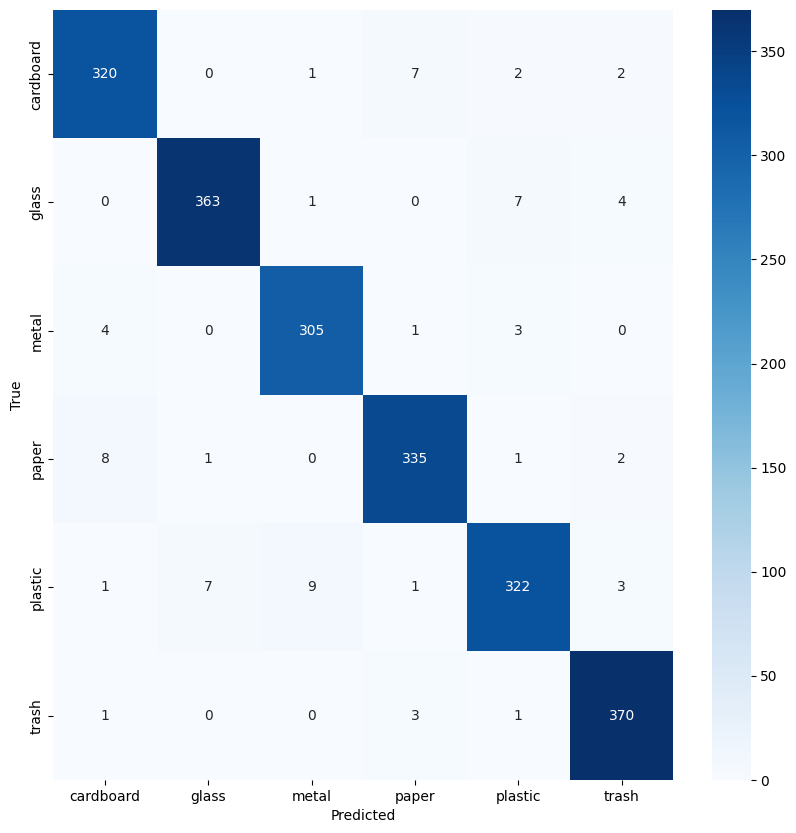

In [23]:
#matplotlib confusion matriz with tags
import seaborn as sns
plt.figure(figsize=(10,10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=train_ds.class2idx.keys(), yticklabels=train_ds.class2idx.keys())
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [30]:

ckpt_path = Path('/content/outputs/effv2s_256/best.pt')
ckpt = torch.load(ckpt_path, map_location='cpu')
class2idx = ckpt['class2idx']
idx2class = {v:k for k,v in class2idx.items()}

model = timm.create_model(model_name, pretrained=False, num_classes=len(class2idx))
model.load_state_dict(ckpt['model']); model.eval()

dummy = torch.randn(1,3,256,256)
# TorchScript
traced = torch.jit.trace(model, dummy)
Path('outputs').mkdir(exist_ok=True, parents=True)
traced.save("outputs/model_ts.pt")
# ONNX
%pip install onnx
%pip install onnxruntime
import onnx
import onnxruntime as ort
torch.onnx.export(model, dummy, "outputs/model.onnx",
                  input_names=["input"], output_names=["logits"],
                  opset_version=17, dynamic_axes={"input":{0:"batch"}, "logits":{0:"batch"}})

"Exportado a outputs/model_ts.pt y outputs/model.onnx"


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 113.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.4/17.4 MB 128.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 9.5 MB/s eta 0:00:00


/tmp/ipython-input-4053980888.py:19: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter will be the default. To switch now, set dynamo=True in torch.onnx.export. This new exporter supports features like exporting LLMs with DynamicCache. We encourage you to try it and share feedback to help improve the experience. Learn more about the new export logic: https://pytorch.org/docs/stable/onnx_dynamo.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html.
  torch.onnx.export(model, dummy, "outputs/model.onnx",


'Exportado a outputs/model_ts.pt y outputs/model.onnx'

In [36]:
@torch.no_grad()
def load_model_for_infer(ckpt_path):
    ckpt = torch.load(ckpt_path, map_location=device)
    class2idx = ckpt['class2idx']
    idx2class = {v:k for k,v in class2idx.items()}
    model = timm.create_model(model_name, pretrained=False, num_classes=len(class2idx)).to(device)
    model.load_state_dict(ckpt['model']); model.eval()
    tfm = get_val_transforms(IMG_SIZE)
    return model, tfm, idx2class

def predict_image(model, tfm, img_path, idx2class):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    x = tfm(image=img)['image'].unsqueeze(0).to(device)
    logits = model(x)
    probs = torch.softmax(logits, dim=1).squeeze(0).cpu().detach().numpy()
    pred_idx = int(np.argmax(probs))
    return idx2class[pred_idx], probs

model, tfm, idx2class = load_model_for_infer('outputs/effv2s_256/best.pt')
# model, tfm, idx2class, cfg = load_model_for_infer('outputs/pt')

# Ejemplo:
test_path = test_df.iloc[0]['filepath']
pred, probs = predict_image(model, tfm, test_path, idx2class)
pred, probs.max(), test_path

('plastic',
 np.float32(0.905688),
 '/content/data/raw/plastic/plastic_02092.jpg')